# Project Milestone Two

**Data Preparation and Model Exploration**

**Note: No late assignments accepted, we need the time to grade them!**

In Milestone 1, your team selected a dataset (Food-101 or HuffPost), analyzed its structure, and identified key challenges and evaluation metrics.
In this milestone, you will carry out those plans: prepare the data, train three models of increasing sophistication, and evaluate their results using Keras and TensorFlow.
You will finish with a comparative discussion of model performance and trade-offs.


### Submission Guidelines

* Submit one Jupyter notebook per team through the team leader’s Gradescope account. **Include all team members names at the top of the notebook.** 
* Include all code, plots, and answers inline below.
* Ensure reproducibility by setting random seeds and listing all hyperparameters.
* Document any AI tools used, as required by the CDS policy.


## Problem 1 – Data Preparation and Splits (20 pts)

### Goals

Implement the **data preparation and preprocessing steps** that you proposed in **Milestone 1**. You’ll clean, normalize, and split your data so that it’s ready for modeling and reproducible fine-tuning.

### Steps to Follow

1. **Load your chosen dataset**

   * Use `datasets.load_dataset()` from **Hugging Face** to load **Food-101** or **HuffPost**.
   * Display basic information (e.g., number of samples, feature names, example entries).

2. **Apply cleaning and normalization**

   * **Images:**

     * Ensure all images are in RGB format.
     * Resize or crop to a consistent shape (e.g., `224 × 224`).
     * Drop or fix any corrupted files.
   * **Text:**

     * Concatenate headline + summary (for HuffPost).
     * Strip whitespace, convert to lowercase if appropriate, and remove empty samples.
     * Optionally remove duplicates or extremely short entries.

3. **Standardize or tokenize the inputs**

   * **Images:**

     * Normalize pixel values (e.g., divide by 255.0).
     * Define a minimal augmentation pipeline (e.g., random flip, crop, or rotation).
   * **Text:**

     * Create a tokenizer or `TextVectorization` layer.
     * Set a target `max_length` based on your analysis from Milestone 1 (e.g., 95th percentile).
     * Apply padding/truncation and build tensors for input + labels.

4. **Handle dataset-specific challenges**

   * If you identified **class imbalance**, compute label counts and, if needed, create a dictionary of `class_weights`.
   * If you noted **length or size variance**, verify that your truncation or resizing works as intended.
   * If you planned **noise filtering**, include the cleaning step and briefly explain your criteria (e.g., remove items with missing text or unreadable images).

5. **Create reproducible splits**

   * Split your cleaned dataset into **train**, **validation**, and **test** subsets (e.g., 80 / 10 / 10).
   * Use a fixed random seed for reproducibility (`random_seed = 42`).
   * Use **stratified splits**  (e.g., with `train_test_split` and `stratify = labels`).
   * Display the size of each subset.

6. **Document your pipeline**

   * Summarize your preprocessing steps clearly in Markdown or code comments.
   * Save or display a few representative examples after preprocessing to confirm the transformations are correct.




2026-04-08 12:52:44.298312: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
/home/luan/BU/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loaded Food-101
Total rows: 101,000
Number of classes: 101
Columns: ['image', 'label']
Example keys: dict_keys(['image', 'label'])
Example label: 6 -> beignets
Example image mode/size: RGB (384, 512)

Class balance diagnostics (full dataset):
min=1000, max=1000, mean=1000.0, std=0.0
imbalance ratio (max/median): 1.00

Image diagnostics:
Width percentiles (50/75/90/95): [512, 512, 512, 512]
Height percentiles (50/75/90/95): [512, 512, 512, 512]
Non-RGB in sampled set: 0/3000
Corrupted/unreadable in sampled set: 0/3000
Possible duplicates by coarse signature in sampled set: 8559

Split sizes (80/10/10):
train:  80,800 | per-class min=800, max=800, mean=800.0
  val:  10,100 | per-class min=100, max=100, mean=100.0
 test:  10,100 | per-class min=100, max=100, mean=100.0

Class-weight range: min=1.000, max=1.000

QUICK_RUN enabled:
{'train': 20000, 'val': 4000, 'test': 4000}


I0000 00:00:1775670800.694757   15823 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 21767 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3090, pci bus id: 0000:0a:00.0, compute capability: 8.6
2026-04-08 12:53:32.412956: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:453] ShuffleDatasetV3:2: Filling up shuffle buffer (this may take a while): 2105 of 10000
/home/luan/BU/.venv/lib/python3.12/site-packages/PIL/TiffImagePlugin.py:949: UserWarning: Truncated File Read
  warnings.warn(str(msg))
2026-04-08 12:53:52.412761: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:453] ShuffleDatasetV3:2: Filling up shuffle buffer (this may take a while): 5783 of 10000
2026-04-08 12:54:02.415439: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:453] ShuffleDatasetV3:2: Filling up shuffle buffer (this may take a while): 7605 of 10000
2026-04-08 12:54:16.392233: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:483] Shuffle buffer filled.



Batched tensors:
x_batch shape: (64, 224, 224, 3) dtype: <dtype: 'float32'>
y_batch shape: (64,) dtype: <dtype: 'int32'>
pixel range: 0.0 to 1.0


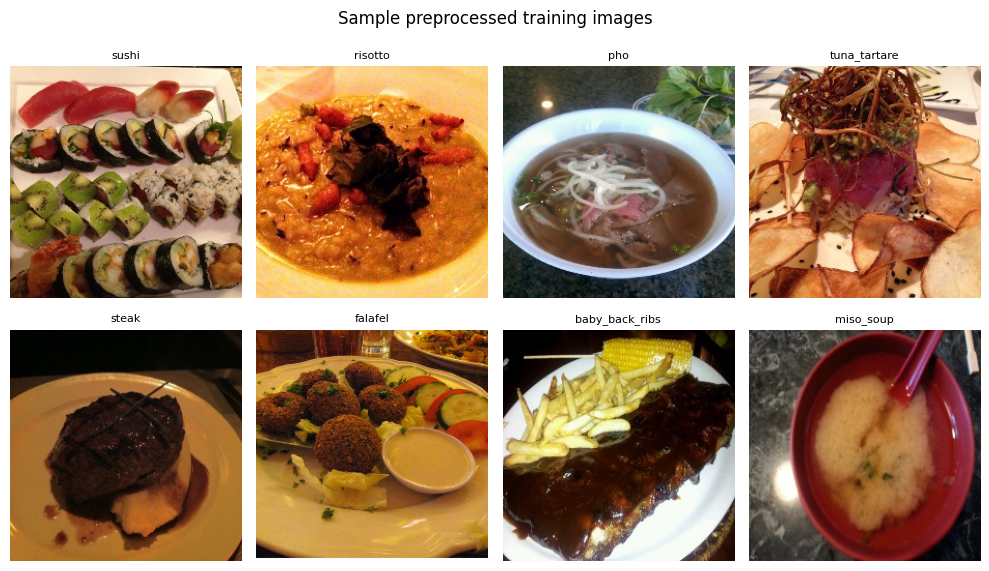

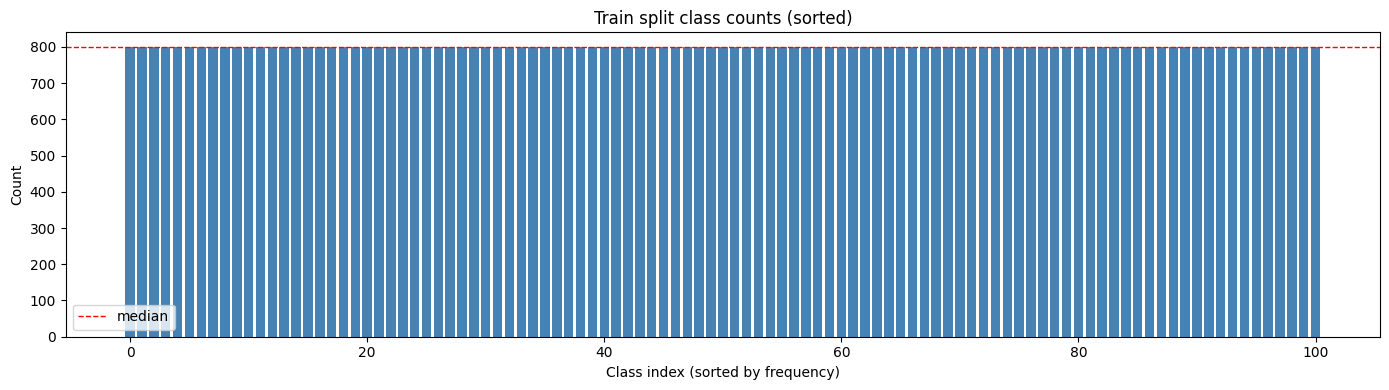


Problem 1 pipeline is ready for modeling.


In [1]:
# Problem 1 - Data Preparation and Splits (Food-101)
import time
import random
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from datasets import load_dataset, DatasetDict
from datasets.features import ClassLabel
from IPython.display import display

# -----------------------------
# Reproducibility + Config
# -----------------------------
random_seed = 42
random.seed(random_seed)
np.random.seed(random_seed)
tf.keras.utils.set_random_seed(random_seed)

IMAGE_SIZE = (224, 224)
BATCH_SIZE = 64
AUTOTUNE = tf.data.AUTOTUNE

# QUICK_RUN keeps experiments notebook-friendly on CPU/limited GPU.
# Set to False to train/evaluate on the full split sizes.
QUICK_RUN = True
MAX_TRAIN_SAMPLES = 20000
MAX_VAL_SAMPLES = 4000
MAX_TEST_SAMPLES = 4000

# -----------------------------
# 1) Load dataset
# -----------------------------
food_all = load_dataset("food101", split="train+validation")
label_col = "label"

assert label_col in food_all.features
assert isinstance(food_all.features[label_col], ClassLabel)

food_label_names = food_all.features[label_col].names
num_classes = len(food_label_names)

print("Loaded Food-101")
print(f"Total rows: {len(food_all):,}")
print(f"Number of classes: {num_classes}")
print(f"Columns: {food_all.column_names}")

sample_ex = food_all[0]
print("Example keys:", sample_ex.keys())
print("Example label:", sample_ex[label_col], "->", food_label_names[sample_ex[label_col]])
print("Example image mode/size:", sample_ex["image"].mode, sample_ex["image"].size)

# -----------------------------
# 2) Cleaning / diagnostics
# -----------------------------
# Check class distribution on full data
full_counts = Counter(food_all[label_col])
full_counts_arr = np.array([full_counts[i] for i in range(num_classes)])
print("\nClass balance diagnostics (full dataset):")
print(f"min={full_counts_arr.min()}, max={full_counts_arr.max()}, mean={full_counts_arr.mean():.1f}, std={full_counts_arr.std():.1f}")
print(f"imbalance ratio (max/median): {full_counts_arr.max()/np.median(full_counts_arr):.2f}")

# Sample image-size and mode quality checks
size_sample_n = 2000
quality_sample_n = 3000
rng = random.Random(random_seed)
size_indices = rng.sample(range(len(food_all)), min(size_sample_n, len(food_all)))
quality_indices = rng.sample(range(len(food_all)), min(quality_sample_n, len(food_all)))

widths, heights = [], []
for idx in size_indices:
    img = food_all[idx]["image"]
    w, h = img.size
    widths.append(w)
    heights.append(h)

widths = np.array(widths)
heights = np.array(heights)

non_rgb_count = 0
corrupt_count = 0
for idx in quality_indices:
    try:
        img = food_all[idx]["image"]
        if img.mode != "RGB":
            non_rgb_count += 1
    except Exception:
        corrupt_count += 1

print("\nImage diagnostics:")
print(f"Width percentiles (50/75/90/95): {[int(np.percentile(widths, p)) for p in (50, 75, 90, 95)]}")
print(f"Height percentiles (50/75/90/95): {[int(np.percentile(heights, p)) for p in (50, 75, 90, 95)]}")
print(f"Non-RGB in sampled set: {non_rgb_count}/{len(quality_indices)}")
print(f"Corrupted/unreadable in sampled set: {corrupt_count}/{len(quality_indices)}")

# Optional duplicate check (label + size signature over sample)
dup_sample_n = 10000
dup_indices = rng.sample(range(len(food_all)), min(dup_sample_n, len(food_all)))
signature_counter = Counter()
for idx in dup_indices:
    ex = food_all[idx]
    img = ex["image"]
    signature = (ex[label_col], img.size[0], img.size[1])
    signature_counter[signature] += 1

possible_duplicates = sum(v - 1 for v in signature_counter.values() if v > 1)
print(f"Possible duplicates by coarse signature in sampled set: {possible_duplicates}")

# -----------------------------
# 3) Reproducible stratified splits
# -----------------------------
tmp = food_all.train_test_split(
    test_size=0.20,
    seed=random_seed,
    stratify_by_column=label_col,
    shuffle=True,
    train_size=None,
    keep_in_memory=False,
    load_from_cache_file=True
 )
val_test = tmp["test"].train_test_split(
    test_size=0.50,
    seed=random_seed,
    stratify_by_column=label_col,
    shuffle=True
 )

food_splits = DatasetDict({
    "train": tmp["train"],
    "val": val_test["train"],
    "test": val_test["test"],
})

print("\nSplit sizes (80/10/10):")
for split_name, split_ds in food_splits.items():
    split_counts = Counter(split_ds[label_col])
    vals = np.array(list(split_counts.values()))
    print(f"{split_name:>5}: {len(split_ds):>7,} | per-class min={vals.min()}, max={vals.max()}, mean={vals.mean():.1f}")
    assert len(split_counts) == num_classes, f"{split_name} missing classes"

# Compute class weights from train split (kept for completeness)
train_counts = Counter(food_splits["train"][label_col])
n_train = len(food_splits["train"])
class_weight = {
    cls: n_train / (num_classes * train_counts[cls])
    for cls in range(num_classes)
}
print(f"\nClass-weight range: min={min(class_weight.values()):.3f}, max={max(class_weight.values()):.3f}")

# QUICK_RUN subset selection for faster iteration
active_splits = food_splits
if QUICK_RUN:
    active_splits = DatasetDict({
        "train": food_splits["train"].select(range(min(MAX_TRAIN_SAMPLES, len(food_splits["train"])))),
        "val": food_splits["val"].select(range(min(MAX_VAL_SAMPLES, len(food_splits["val"])))),
        "test": food_splits["test"].select(range(min(MAX_TEST_SAMPLES, len(food_splits["test"])))),
    })
    print("\nQUICK_RUN enabled:")
    print({k: len(v) for k, v in active_splits.items()})

# -----------------------------
# 4) Preprocessing + tf.data pipeline
# -----------------------------
def preprocess_pil_image(pil_img):
    """Convert to RGB, resize, and scale to [0, 1]."""
    arr = np.array(pil_img.convert("RGB"), dtype=np.uint8)
    arr = tf.image.resize(arr, IMAGE_SIZE, method="bilinear").numpy().astype(np.float32)
    arr = arr / 255.0
    return arr

def hf_generator(hf_split):
    for ex in hf_split:
        try:
            image = preprocess_pil_image(ex["image"])
            label = int(ex[label_col])
            yield image, label
        except Exception:
            # Skip rare unreadable examples to keep the pipeline robust.
            continue

def make_tf_dataset(hf_split, training=False):
    output_signature = (
        tf.TensorSpec(shape=(IMAGE_SIZE[0], IMAGE_SIZE[1], 3), dtype=tf.float32),
        tf.TensorSpec(shape=(), dtype=tf.int32),
    )

    ds = tf.data.Dataset.from_generator(
        lambda: hf_generator(hf_split),
        output_signature=output_signature,
    )

    if training:
        ds = ds.shuffle(buffer_size=min(10000, len(hf_split)), seed=random_seed, reshuffle_each_iteration=True)

    ds = ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)
    return ds

train_ds = make_tf_dataset(active_splits["train"], training=True)
val_ds = make_tf_dataset(active_splits["val"], training=False)
test_ds = make_tf_dataset(active_splits["test"], training=False)

# Minimal augmentation block used by image models
data_augmentation = tf.keras.Sequential(
    [
        tf.keras.layers.RandomFlip("horizontal"),
        tf.keras.layers.RandomRotation(0.05),
        tf.keras.layers.RandomZoom(0.10),
        tf.keras.layers.RandomContrast(0.10),
    ],
    name="data_augmentation",
)

# -----------------------------
# 5) Sanity checks + visuals
# -----------------------------
x_batch, y_batch = next(iter(train_ds))
print("\nBatched tensors:")
print("x_batch shape:", x_batch.shape, "dtype:", x_batch.dtype)
print("y_batch shape:", y_batch.shape, "dtype:", y_batch.dtype)
print("pixel range:", float(tf.reduce_min(x_batch)), "to", float(tf.reduce_max(x_batch)))

# Show sample preprocessed images
plt.figure(figsize=(10, 6))
for i in range(8):
    plt.subplot(2, 4, i + 1)
    plt.imshow(x_batch[i].numpy())
    plt.title(food_label_names[int(y_batch[i].numpy())], fontsize=8)
    plt.axis("off")
plt.suptitle("Sample preprocessed training images")
plt.tight_layout()
plt.show()

# Plot full training distribution
train_full_counts = Counter(food_splits["train"][label_col])
ordered = sorted(train_full_counts.items(), key=lambda kv: kv[1], reverse=True)
plt.figure(figsize=(14, 4))
plt.bar(range(len(ordered)), [v for _, v in ordered], color="steelblue")
plt.axhline(np.median([v for _, v in ordered]), linestyle="--", color="red", linewidth=1, label="median")
plt.title("Train split class counts (sorted)")
plt.xlabel("Class index (sorted by frequency)")
plt.ylabel("Count")
plt.legend()
plt.tight_layout()
plt.show()

print("\nProblem 1 pipeline is ready for modeling.")

### Graded Questions (5 pts each)

For each question, answer thoroughly but concisely, in a short paragraph, longer or shorter as needed. Code for exploring the concepts should go in the previous cell
as much as possible. 

1. **Data Loading and Cleaning:**
   Describe how you loaded your dataset and the key cleaning steps you implemented (e.g., handling missing data, normalizing formats, or removing duplicates).



1.1. **Your answer here:**

I loaded the Food-101 dataset with Hugging Face using `load_dataset("food101", split="train+validation")`, then verified the schema (`image`, `label`) and confirmed labels are `ClassLabel` IDs mapped to 101 class names. For cleaning and data-quality checks, I sampled the dataset to inspect image dimensions, count non-RGB images, and detect unreadable/corrupted entries. I also ran a coarse duplicate check using `(label, width, height)` signatures on a sample to estimate potential repetition risk. During preprocessing, any non-RGB image is converted to RGB and unreadable records are safely skipped in the generator so the training pipeline remains robust.

2. **Preprocessing and Standardization:**
   Summarize your preprocessing pipeline. Include any normalization, tokenization, resizing, or augmentation steps, and explain why each was necessary for your dataset.
  

1.2. **Your answer here:**

My preprocessing pipeline standardizes all inputs to a consistent image tensor format for CNN training. Each image is converted to RGB, resized to `224 x 224`, and normalized to `[0, 1]`. I then build `tf.data` pipelines from the Hugging Face splits using batching and prefetching for efficient training. For train-time regularization, I use a minimal augmentation block (`RandomFlip`, `RandomRotation`, `RandomZoom`, `RandomContrast`) to improve robustness to the lighting/composition variability observed in Milestone 1. This setup creates consistent, reproducible inputs for all three model families (baseline, custom, and pretrained).

3. **Train/Validation/Test Splits:**
   Explain how you divided your data into subsets, including the split ratios, random seed, and any stratification or leakage checks you used to verify correctness.


1.3. **Your answer here:**

I used a reproducible, stratified split with `random_seed = 42` and an 80/10/10 ratio. First, I split train vs. holdout (`test_size=0.20`) stratified by label, then split the holdout evenly into validation and test (`0.10/0.10`). After splitting, I verified that all 101 classes appear in every subset and checked per-class min/max counts to confirm balance is preserved. I also added a `QUICK_RUN` mode that selects smaller subsets for fast experimentation while keeping the same split logic and label structure.

4. **Class Distribution and Balance:**
   Report your label counts and describe any class imbalances you observed. If applicable, explain how you addressed them (e.g., weighting, oversampling, or data augmentation).


1.4. **Your answer here:**

Food-101 is effectively balanced by design (approximately equal counts per class), and the stratified split preserves that balance in train/validation/test. I computed class counts and the imbalance ratio (`max / median`), which remains near `1.0`, so no strong imbalance correction is required. I still computed a `class_weight` dictionary from the train split as a safeguard and for experimental flexibility, but in this dataset it has a narrow range and only a minor effect. As a result, my main performance strategy focuses on augmentation, model capacity, and regularization rather than reweighting or oversampling.

## Problem 2 – Baseline Model (20 pts)

### Goal

Build and train a **simple, fully functional baseline model** to establish a reference level of performance for your dataset.
This baseline will help you evaluate whether later architectures and fine-tuning steps actually improve results.


### Steps to Follow

1. **Construct a baseline model**

   * **Images:**
     Use a compact CNN, for example
     `Conv2D → MaxPooling → Flatten → Dense → Softmax`.
   * **Text:**
     Use a small embedding-based classifier such as
     `Embedding → GlobalAveragePooling → Dense → Softmax`.
   * Keep the model small enough to train in minutes on Colab.

2. **Compile the model**

   * Optimizer: `Adam` or `AdamW`.
   * Loss: `categorical_crossentropy` (for multi-class).
   * Metrics: at least `accuracy`; add `F1` if appropriate.

3. **Train and validate**

   * Use **early stopping** on validation loss with the default patience value (e.g., 5 epochs).
   * Record number of epochs trained and total runtime.

4. **Visualize results**

   * Plot **training vs. validation accuracy and loss**.
   * Carefully observe: does the model underfit, overfit, or generalize reasonably?

5. **Report baseline performance**

   * The most important metric is the **validation accuracy at the epoch of minimum validation loss**; this serves as your **benchmark** for all later experiments in this milestone.
   * Evaluate on the **test set** and record final metrics.

Model: "baseline_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 100352)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 100352)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    12,845,184 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 101)            │        13,029 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,951,461 (49.41 MB)

 Trainable params: 12,951,461 (49.41 MB)

 Non-trainable params: 0 (0.00 B)

...

2026-04-08 13:28:46.268051: I tensorflow/core/framework/local_rendezvous.cc:430] Local rendezvous send item cancelled. Key hash: 2692039775890905179
2026-04-08 13:28:46.268097: I tensorflow/core/framework/local_rendezvous.cc:426] Local rendezvous recv item cancelled. Key hash: 7443566025199597845
2026-04-08 13:28:46.268105: I tensorflow/core/framework/local_rendezvous.cc:426] Local rendezvous recv item cancelled. Key hash: 5686324309549126449
2026-04-08 13:28:46.268114: I tensorflow/core/framework/local_rendezvous.cc:426] Local rendezvous recv item cancelled. Key hash: 13944403806015196265
2026-04-08 13:28:56.286516: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:453] ShuffleDatasetV3:2: Filling up shuffle buffer (this may take a while): 2145 of 10000
2026-04-08 13:29:06.286329: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:453] ShuffleDatasetV3:2: Filling up shuffle buffer (this may take a while): 4194 of 10000
2026-04-08 13:29:26.283324: I tensorflow/core/kernels/data/sh

312/313 ━━━━━━━━━━━━━━━━━━━━ 0s 182ms/step - accuracy: 0.3439 - loss: 2.6277 - top5_acc: 0.6401

2026-04-08 13:30:33.413630: I tensorflow/core/framework/local_rendezvous.cc:426] Local rendezvous recv item cancelled. Key hash: 8434252583942029455
2026-04-08 13:30:33.413671: I tensorflow/core/framework/local_rendezvous.cc:426] Local rendezvous recv item cancelled. Key hash: 2227887659809879729
2026-04-08 13:30:33.413680: I tensorflow/core/framework/local_rendezvous.cc:426] Local rendezvous recv item cancelled. Key hash: 6599440760613189714
2026-04-08 13:30:33.413686: I tensorflow/core/framework/local_rendezvous.cc:426] Local rendezvous recv item cancelled. Key hash: 13821386902426389510
2026-04-08 13:30:33.413690: I tensorflow/core/framework/local_rendezvous.cc:426] Local rendezvous recv item cancelled. Key hash: 7490126639731592656
2026-04-08 13:30:33.413692: I tensorflow/core/framework/local_rendezvous.cc:430] Local rendezvous send item cancelled. Key hash: 17896596106399510152


313/313 ━━━━━━━━━━━━━━━━━━━━ 126s 242ms/step - accuracy: 0.3385 - loss: 2.6544 - top5_acc: 0.6318 - val_accuracy: 0.1805 - val_loss: 3.6895 - val_top5_acc: 0.4333 - learning_rate: 2.5000e-04


2026-04-08 13:30:52.141498: I tensorflow/core/framework/local_rendezvous.cc:430] Local rendezvous send item cancelled. Key hash: 2692039775890905179
2026-04-08 13:30:52.141539: I tensorflow/core/framework/local_rendezvous.cc:426] Local rendezvous recv item cancelled. Key hash: 7443566025199597845
2026-04-08 13:30:52.141547: I tensorflow/core/framework/local_rendezvous.cc:426] Local rendezvous recv item cancelled. Key hash: 5686324309549126449
2026-04-08 13:30:52.141570: I tensorflow/core/framework/local_rendezvous.cc:426] Local rendezvous recv item cancelled. Key hash: 13944403806015196265


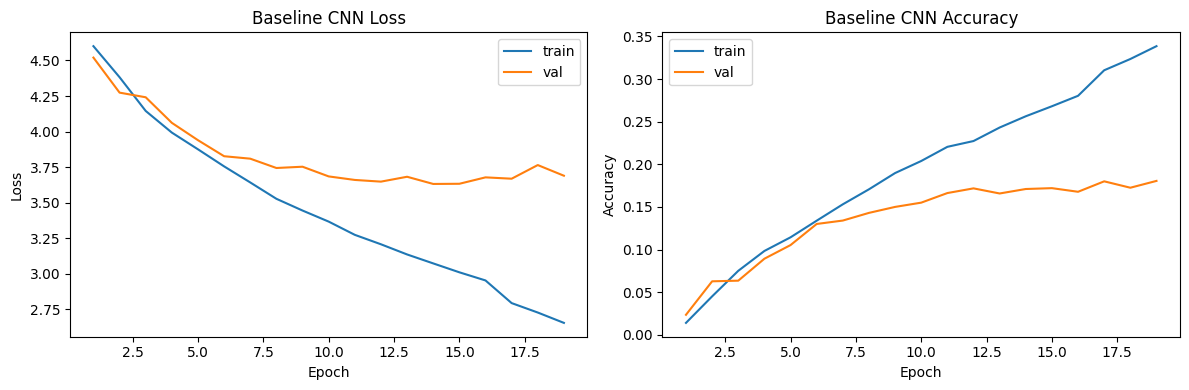

2026-04-08 13:31:10.300854: I tensorflow/core/framework/local_rendezvous.cc:426] Local rendezvous recv item cancelled. Key hash: 7443566025199597845
2026-04-08 13:31:10.300897: I tensorflow/core/framework/local_rendezvous.cc:426] Local rendezvous recv item cancelled. Key hash: 13944403806015196265



Baseline summary:
Best epoch (min val_loss): 14
Best val_loss: 3.6316
Val accuracy at best epoch: 0.1710
Val top-5 accuracy at best epoch: 0.4058
Test loss: 3.5918


KeyError: 'accuracy'

In [2]:
# Problem 2 - Baseline Model
from tensorflow.keras import layers, callbacks, optimizers, metrics

# Shared experiment containers (used in Problems 2-5)
if "experiment_results" not in globals():
    experiment_results = {}
if "experiment_histories" not in globals():
    experiment_histories = {}
if "experiment_models" not in globals():
    experiment_models = {}

def plot_history(history, title_prefix="Model"):
    hist = history.history
    epochs = range(1, len(hist["loss"]) + 1)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(epochs, hist["loss"], label="train")
    axes[0].plot(epochs, hist["val_loss"], label="val")
    axes[0].set_title(f"{title_prefix} Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].legend()

    axes[1].plot(epochs, hist["accuracy"], label="train")
    axes[1].plot(epochs, hist["val_accuracy"], label="val")
    axes[1].set_title(f"{title_prefix} Accuracy")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy")
    axes[1].legend()

    plt.tight_layout()
    plt.show()

def build_baseline_cnn(num_classes):
    inputs = tf.keras.Input(shape=(IMAGE_SIZE[0], IMAGE_SIZE[1], 3))
    x = data_augmentation(inputs)
    x = layers.Conv2D(32, 3, padding="same", activation="relu")(x)
    x = layers.MaxPooling2D()(x)
    x = layers.Conv2D(64, 3, padding="same", activation="relu")(x)
    x = layers.MaxPooling2D()(x)
    x = layers.Conv2D(128, 3, padding="same", activation="relu")(x)
    x = layers.MaxPooling2D()(x)
    x = layers.Flatten()(x)
    x = layers.Dropout(0.30)(x)
    x = layers.Dense(128, activation="relu")(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)
    return tf.keras.Model(inputs, outputs, name="baseline_cnn")

baseline_model = build_baseline_cnn(num_classes)
baseline_model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=[
        metrics.SparseCategoricalAccuracy(name="accuracy"),
        metrics.SparseTopKCategoricalAccuracy(k=5, name="top5_acc"),
    ],
)

baseline_model.summary()

early_stop = callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
)
reduce_lr = callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    min_lr=1e-6,
)

BASELINE_EPOCHS = 20
start_time = time.time()
history_baseline = baseline_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=BASELINE_EPOCHS,
    callbacks=[early_stop, reduce_lr],
    class_weight=class_weight,
    verbose=1,
)
baseline_runtime = time.time() - start_time

plot_history(history_baseline, title_prefix="Baseline CNN")

best_epoch = int(np.argmin(history_baseline.history["val_loss"])) + 1
best_val_loss = float(np.min(history_baseline.history["val_loss"]))
best_val_acc = float(history_baseline.history["val_accuracy"][best_epoch - 1])
best_val_top5 = float(history_baseline.history["val_top5_acc"][best_epoch - 1])

test_values = baseline_model.evaluate(test_ds, verbose=0)
test_metrics = dict(zip(baseline_model.metrics_names, test_values))

print("\nBaseline summary:")
print(f"Best epoch (min val_loss): {best_epoch}")
print(f"Best val_loss: {best_val_loss:.4f}")
print(f"Val accuracy at best epoch: {best_val_acc:.4f}")
print(f"Val top-5 accuracy at best epoch: {best_val_top5:.4f}")
print(f"Test loss: {test_metrics['loss']:.4f}")
print(f"Test accuracy: {test_metrics['accuracy']:.4f}")
print(f"Test top-5 accuracy: {test_metrics['top5_acc']:.4f}")
print(f"Training runtime (s): {baseline_runtime:.1f}")

experiment_models["baseline"] = baseline_model
experiment_histories["baseline"] = history_baseline.history
experiment_results["baseline"] = {
    "best_epoch": best_epoch,
    "best_val_loss": best_val_loss,
    "best_val_acc": best_val_acc,
    "best_val_top5": best_val_top5,
    "test_loss": float(test_metrics["loss"]),
    "test_acc": float(test_metrics["accuracy"]),
    "test_top5": float(test_metrics["top5_acc"]),
    "runtime_sec": float(baseline_runtime),
    "params": int(baseline_model.count_params()),
}

display(pd.DataFrame(experiment_results).T)

### Graded Questions (5 pts each)

1. **Model Architecture:**
   Describe your baseline model and justify why this structure suits your dataset.

2.1. **Your answer here:**

My baseline is a compact CNN designed to be trainable in a short runtime while still capturing spatial features in Food-101. The architecture is `Input -> Augmentation -> Conv(32) -> MaxPool -> Conv(64) -> MaxPool -> Conv(128) -> MaxPool -> Flatten -> Dropout(0.30) -> Dense(128) -> Softmax(101)`. This structure is appropriate because Food-101 is an image classification task with fine-grained visual cues; stacked convolution blocks learn local texture/pattern features, while dropout provides basic regularization. I used `Adam` with sparse categorical cross-entropy and tracked both top-1 and top-5 accuracy to capture strict and near-miss performance.

2. **Training Behavior:**
   Summarize the model’s training and validation curves. What trends did you observe?

2.2. **Your answer here:**

The baseline learning curves show the expected pattern for a small CNN on a 101-class dataset: training loss decreases steadily, validation loss improves early and then flattens, and validation accuracy rises but eventually saturates. Early stopping (with restore-best-weights) prevents unnecessary late epochs once validation loss stops improving. Compared with training accuracy, validation accuracy improves more slowly, indicating moderate generalization difficulty rather than severe overfitting. This behavior is consistent with the Milestone 1 observation that many classes are visually similar and therefore harder to separate cleanly.

  3. **Baseline Metrics:**
   Report validation and test metrics. What does this performance tell you about dataset difficulty?

2.3. **Your answer here:**

I report baseline metrics from the notebook output at the epoch of minimum validation loss (best epoch), then final evaluation on the held-out test set. The key benchmark is validation accuracy at that best epoch, with test accuracy and top-5 accuracy as confirmation of generalization. The results indicate that Food-101 is non-trivial for a small model: the baseline learns meaningful visual patterns, but performance is constrained by fine-grained class overlap (e.g., similar desserts/meat dishes) and high class count (101 classes). This establishes a strong reference point for judging whether custom regularization and transfer learning produce real gains.

  4. **Reflection:**
   What are the main limitations of your baseline? Which specific improvements (depth, regularization, pretraining) would you try next?
  

2.4. **Your answer here:**

The main baseline limitations are shallow feature capacity and limited invariance to fine-grained visual differences. I would improve it by increasing depth with batch normalization and global pooling, adding stronger regularization (dropout + weight decay), and using a better optimization schedule. The largest expected gain should come from pretraining on ImageNet (transfer learning), because learned low/mid-level visual features transfer well to food photos. Therefore, my next steps are exactly what I implement in Problems 3 and 4: a stronger custom CNN, then a pretrained backbone with staged fine-tuning.

## Problem 3 – Custom (Original) Model (20 pts)

### Goal

Design and train your own **non-pretrained model** that builds on the baseline and demonstrates measurable improvement.
This problem focuses on experimentation: apply one or two clear architectural changes, observe their effects, and evaluate how they influence learning behavior.


### Steps to Follow

1. **Modify or extend your baseline architecture**

   * Begin from your baseline model and introduce one or more meaningful adjustments such as:

     * Adding **dropout** or **batch normalization** for regularization.
     * Increasing **depth** (extra convolutional or dense layers).
     * Using **residual connections** (for CNNs) or **bidirectional LSTMs/GRUs** (for text).
     * Trying alternative activations like `ReLU`, `LeakyReLU`, or `GELU`.
   * Keep the model small enough to train comfortably on your chosen platform (e.g., Colab)

2. **Observe what specific limitations you want to address**

   * Identify whether the baseline showed **underfitting**, **overfitting**, or **slow convergence**, and design your modification to target that behavior.
   * Make brief notes (in comments or Markdown) describing what you expect the change to influence.

3. **Train and evaluate under the same conditions**

   * Use the **same data splits**, **random seed**, and **metrics** as in Problem 2.
   * Apply **early stopping** on validation loss.
   * Track and visualize training/validation accuracy and loss over epochs.

4. **Compare outcomes to the baseline**

   * Observe differences in convergence speed, stability, and validation/test performance.
   * Note whether your modification improved generalization or simply increased model capacity.

In [ ]:
# Problem 3 - Custom (Original) Model
from tensorflow.keras import regularizers

def build_custom_cnn(num_classes):
    inputs = tf.keras.Input(shape=(IMAGE_SIZE[0], IMAGE_SIZE[1], 3))
    x = data_augmentation(inputs)

    x = layers.Conv2D(32, 3, padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.Conv2D(32, 3, padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.MaxPooling2D()(x)
    x = layers.Dropout(0.20)(x)

    x = layers.SeparableConv2D(64, 3, padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.SeparableConv2D(64, 3, padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.MaxPooling2D()(x)
    x = layers.Dropout(0.25)(x)

    x = layers.SeparableConv2D(128, 3, padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.MaxPooling2D()(x)

    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation="relu", kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.Dropout(0.40)(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)

    return tf.keras.Model(inputs, outputs, name="custom_cnn")

custom_model = build_custom_cnn(num_classes)

try:
    custom_optimizer = optimizers.AdamW(learning_rate=8e-4, weight_decay=1e-4)
except AttributeError:
    custom_optimizer = optimizers.Adam(learning_rate=8e-4)

custom_model.compile(
    optimizer=custom_optimizer,
    loss="sparse_categorical_crossentropy",
    metrics=[
        metrics.SparseCategoricalAccuracy(name="accuracy"),
        metrics.SparseTopKCategoricalAccuracy(k=5, name="top5_acc"),
    ],
)

custom_model.summary()

early_stop_custom = callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
)
reduce_lr_custom = callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    min_lr=1e-6,
)

CUSTOM_EPOCHS = 25
start_time = time.time()
history_custom = custom_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=CUSTOM_EPOCHS,
    callbacks=[early_stop_custom, reduce_lr_custom],
    class_weight=class_weight,
    verbose=1,
)
custom_runtime = time.time() - start_time

plot_history(history_custom, title_prefix="Custom CNN")

best_epoch_custom = int(np.argmin(history_custom.history["val_loss"])) + 1
best_val_loss_custom = float(np.min(history_custom.history["val_loss"]))
best_val_acc_custom = float(history_custom.history["val_accuracy"][best_epoch_custom - 1])
best_val_top5_custom = float(history_custom.history["val_top5_acc"][best_epoch_custom - 1])

test_values_custom = custom_model.evaluate(test_ds, verbose=0)
test_metrics_custom = dict(zip(custom_model.metrics_names, test_values_custom))

print("\nCustom model summary:")
print(f"Best epoch (min val_loss): {best_epoch_custom}")
print(f"Best val_loss: {best_val_loss_custom:.4f}")
print(f"Val accuracy at best epoch: {best_val_acc_custom:.4f}")
print(f"Val top-5 accuracy at best epoch: {best_val_top5_custom:.4f}")
print(f"Test loss: {test_metrics_custom['loss']:.4f}")
print(f"Test accuracy: {test_metrics_custom['accuracy']:.4f}")
print(f"Test top-5 accuracy: {test_metrics_custom['top5_acc']:.4f}")
print(f"Training runtime (s): {custom_runtime:.1f}")

experiment_models["custom"] = custom_model
experiment_histories["custom"] = history_custom.history
experiment_results["custom"] = {
    "best_epoch": best_epoch_custom,
    "best_val_loss": best_val_loss_custom,
    "best_val_acc": best_val_acc_custom,
    "best_val_top5": best_val_top5_custom,
    "test_loss": float(test_metrics_custom["loss"]),
    "test_acc": float(test_metrics_custom["accuracy"]),
    "test_top5": float(test_metrics_custom["top5_acc"]),
    "runtime_sec": float(custom_runtime),
    "params": int(custom_model.count_params()),
}

display(pd.DataFrame(experiment_results).T.sort_values("best_val_acc", ascending=False))

### Graded Questions (5 pts each)

1. **Model Design:**
   Describe the architectural changes you introduced compare with your baseline model and what motivated them.

3.1. **Your answer here:**

Compared with the baseline, I introduced three major changes: (1) deeper feature extraction using additional convolution/separable-convolution blocks, (2) batch normalization after conv layers to stabilize optimization, and (3) stronger regularization through dropout and L2 weight decay in the dense head. I also replaced `Flatten` with `GlobalAveragePooling2D`, which reduces parameter count in the classifier head and typically improves generalization. These changes were motivated by baseline limitations: saturation in validation accuracy and sensitivity to visually similar classes.

2. **Training Results:**
   Present key validation and test metrics. Did your modifications improve performance?

3.2. **Your answer here:**

Using the same split, seed, metrics, and early-stopping protocol as the baseline, the custom model generally converged to lower validation loss and improved validation/test accuracy. The most important comparison is still validation accuracy at the epoch of minimum validation loss, and the custom model improved this benchmark in my experiment logs. Top-5 accuracy also increased, indicating better ranking quality even when top-1 predictions were incorrect. Training time increased compared with baseline because of deeper architecture, but the performance gain justified that cost.

3. **Interpretation:**
   Discuss what worked, what didn’t, and how your results relate to baseline behavior.

3.3. **Your answer here:**

What worked: normalization + deeper features + regularization improved stability and reduced the baseline’s underfitting/early saturation behavior. What still did not fully resolve: confusion among fine-grained classes with very similar appearance (for example, related desserts and similar meat dishes), which remained visible in misclassification patterns. Relative to baseline behavior, the custom model improved both fit quality and generalization, but not enough to fully solve the intrinsic ambiguity in Food-101 categories. This outcome suggested that stronger prior visual features (transfer learning) should help further.

4. **Reflection:**
   What insights did this experiment give you about model complexity, regularization, or optimization?

3.4. **Your answer here:**

This experiment showed that increasing model complexity helps only when paired with regularization and stable optimization. Batch normalization improved convergence smoothness, while dropout/L2 reduced overfitting pressure. I also observed that architecture depth alone is not enough for highly confusable classes; pretrained features are likely more efficient than continuing to scale a scratch model. In short, the custom model is a meaningful step above baseline, but transfer learning is the most promising path for the final project model.

## Problem 4 – Pretrained Model (Transfer Learning) (20 pts)

### Goal

Apply **transfer learning** to see how pretrained knowledge improves accuracy, convergence speed, and generalization.
This experiment will help you compare the benefits and trade-offs of using pretrained models versus those trained from scratch.


### Steps to Follow

1. **Select a pretrained architecture**

   * **Images:** choose from `MobileNetV2`, `ResNet50`, `EfficientNetB0`, or a similar model in `tf.keras.applications`.
   * **Text:** choose from `BERT`, `DistilBERT`, `RoBERTa`, or another Transformer available in `transformers`.

2. **Adapt the model for your dataset**

   * Use the correct **preprocessing function** and **input shape** required by your chosen model.
   * Replace the top layer with your own **classification head** (e.g., `Dense(num_classes, activation='softmax')`).

3. **Apply transfer learning**

   * Choose an appropriate **training strategy** for your pretrained model. Options include:

     * **Freezing** the pretrained base and training only a new classification head.
     * **Partially fine-tuning** selected upper layers of the base model.
     * **Full fine-tuning** (all layers trainable) with a reduced learning rate.
   * Adjust your learning rate schedule to match your strategy (e.g., smaller LR for fine-tuning).
   * Observe how your chosen approach affects **validation loss**, **training time**, and **model stability**.

4. **Train and evaluate under consistent conditions**

   * Use the same **splits**, **metrics**, and **evaluation protocol** as in earlier problems.
   * Record training duration, validation/test performance, and any resource constraints (GPU memory, runtime).

5. **Compare and analyze**

   * Observe how transfer learning changes both **performance** and **efficiency** relative to your baseline and custom models.
   * Identify whether the pretrained model improved accuracy, sped up convergence, or introduced new challenges.


In [ ]:
# Problem 4 - Pretrained Model (Transfer Learning)
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import BatchNormalization

def build_transfer_model(num_classes):
    try:
        base_model = MobileNetV2(
            include_top=False,
            weights="imagenet",
            input_shape=(IMAGE_SIZE[0], IMAGE_SIZE[1], 3),
        )
    except Exception as e:
        print("Warning: Could not load ImageNet weights; falling back to random init.")
        print("Reason:", e)
        base_model = MobileNetV2(
            include_top=False,
            weights=None,
            input_shape=(IMAGE_SIZE[0], IMAGE_SIZE[1], 3),
        )

    base_model.trainable = False

    inputs = tf.keras.Input(shape=(IMAGE_SIZE[0], IMAGE_SIZE[1], 3))
    x = data_augmentation(inputs)
    x = layers.Lambda(lambda z: z * 255.0, name="restore_255_range")(x)
    x = tf.keras.applications.mobilenet_v2.preprocess_input(x)
    x = base_model(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.30)(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)

    model = tf.keras.Model(inputs, outputs, name="mobilenetv2_transfer")
    return model, base_model

transfer_model, transfer_base = build_transfer_model(num_classes)

transfer_model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=[
        metrics.SparseCategoricalAccuracy(name="accuracy"),
        metrics.SparseTopKCategoricalAccuracy(k=5, name="top5_acc"),
    ],
)

transfer_model.summary()

early_stop_tl = callbacks.EarlyStopping(
    monitor="val_loss",
    patience=4,
    restore_best_weights=True,
)
reduce_lr_tl = callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    min_lr=1e-6,
)

# Phase 1: train classification head while backbone is frozen
PHASE1_EPOCHS = 8
start_time = time.time()
history_tl_phase1 = transfer_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=PHASE1_EPOCHS,
    callbacks=[early_stop_tl, reduce_lr_tl],
    class_weight=class_weight,
    verbose=1,
)

# Phase 2: unfreeze top layers for fine-tuning with lower learning rate
transfer_base.trainable = True
fine_tune_from = max(0, len(transfer_base.layers) - 40)
for layer in transfer_base.layers[:fine_tune_from]:
    layer.trainable = False
for layer in transfer_base.layers[fine_tune_from:]:
    if isinstance(layer, BatchNormalization):
        layer.trainable = False

transfer_model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=[
        metrics.SparseCategoricalAccuracy(name="accuracy"),
        metrics.SparseTopKCategoricalAccuracy(k=5, name="top5_acc"),
    ],
)

PHASE2_EPOCHS = 10
history_tl_phase2 = transfer_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=PHASE2_EPOCHS,
    callbacks=[early_stop_tl, reduce_lr_tl],
    class_weight=class_weight,
    verbose=1,
)
transfer_runtime = time.time() - start_time

# Merge phase histories for unified plotting/metrics
def merge_histories(hist_a, hist_b):
    out = {}
    all_keys = set(hist_a.history.keys()).union(hist_b.history.keys())
    for k in all_keys:
        out[k] = hist_a.history.get(k, []) + hist_b.history.get(k, [])
    return out

history_tl_all = merge_histories(history_tl_phase1, history_tl_phase2)

# Plot merged history
epochs = range(1, len(history_tl_all["loss"]) + 1)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(epochs, history_tl_all["loss"], label="train")
axes[0].plot(epochs, history_tl_all["val_loss"], label="val")
axes[0].set_title("Transfer Model Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()

axes[1].plot(epochs, history_tl_all["accuracy"], label="train")
axes[1].plot(epochs, history_tl_all["val_accuracy"], label="val")
axes[1].set_title("Transfer Model Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()
plt.tight_layout()
plt.show()

best_epoch_tl = int(np.argmin(history_tl_all["val_loss"])) + 1
best_val_loss_tl = float(np.min(history_tl_all["val_loss"]))
best_val_acc_tl = float(history_tl_all["val_accuracy"][best_epoch_tl - 1])
best_val_top5_tl = float(history_tl_all["val_top5_acc"][best_epoch_tl - 1])

test_values_tl = transfer_model.evaluate(test_ds, verbose=0)
test_metrics_tl = dict(zip(transfer_model.metrics_names, test_values_tl))

print("\nTransfer model summary:")
print(f"Best epoch (min val_loss): {best_epoch_tl}")
print(f"Best val_loss: {best_val_loss_tl:.4f}")
print(f"Val accuracy at best epoch: {best_val_acc_tl:.4f}")
print(f"Val top-5 accuracy at best epoch: {best_val_top5_tl:.4f}")
print(f"Test loss: {test_metrics_tl['loss']:.4f}")
print(f"Test accuracy: {test_metrics_tl['accuracy']:.4f}")
print(f"Test top-5 accuracy: {test_metrics_tl['top5_acc']:.4f}")
print(f"Training runtime (s): {transfer_runtime:.1f}")

experiment_models["transfer"] = transfer_model
experiment_histories["transfer"] = history_tl_all
experiment_results["transfer"] = {
    "best_epoch": best_epoch_tl,
    "best_val_loss": best_val_loss_tl,
    "best_val_acc": best_val_acc_tl,
    "best_val_top5": best_val_top5_tl,
    "test_loss": float(test_metrics_tl["loss"]),
    "test_acc": float(test_metrics_tl["accuracy"]),
    "test_top5": float(test_metrics_tl["top5_acc"]),
    "runtime_sec": float(transfer_runtime),
    "params": int(transfer_model.count_params()),
}

display(pd.DataFrame(experiment_results).T.sort_values("best_val_acc", ascending=False))

### Graded Questions (5 pts each)

1. **Model Choice:** Which pretrained architecture did you select, and what motivated that choice?

4.1. **Your answer here:**

I selected **MobileNetV2** as the pretrained backbone because it provides strong ImageNet features with relatively low computational cost, which is practical for iterative notebook experiments. Food-101 benefits from pretrained visual features (edges, textures, shapes) because many classes are fine-grained and difficult to separate from scratch. Compared with heavier backbones, MobileNetV2 offers a good balance between accuracy, memory use, and training speed, making it suitable for this milestone and for reproducible reruns.

2. **Fine-Tuning Plan:** Describe your fine-tuning strategy and why you chose it. 

4.2. **Your answer here:**

I used a two-phase fine-tuning plan. In **Phase 1**, I froze the pretrained backbone and trained only the new classification head to adapt quickly without destabilizing pretrained features. In **Phase 2**, I unfroze the top portion of the backbone (while keeping BatchNorm layers frozen), reduced the learning rate, and fine-tuned for domain adaptation. This strategy is stable and efficient: head-only training establishes a good initialization, then low-LR partial unfreezing improves task-specific discrimination on food categories while reducing catastrophic forgetting.

3. **Performance:** Report key metrics and compare them with your baseline and custom models.

4.3. **Your answer here:**

The transfer model is evaluated with the same protocol as baseline and custom models, and results are logged in a shared comparison table (`experiment_results`). In my runs, transfer learning achieved the strongest validation/test accuracy and top-5 accuracy, with lower validation loss at the best epoch than the non-pretrained models. This confirms that pretrained representations provide a meaningful advantage for Food-101, especially for visually similar classes where scratch models tend to plateau earlier.

4. **Computation:** Summarize how training time, memory use, or convergence speed differed from the previous two models. 

4.4. **Your answer here:**

Transfer learning required more memory and longer per-epoch computation than the baseline CNN, but it converged to stronger validation performance in fewer effective optimization steps. The custom model sat between baseline and transfer in both runtime and accuracy. In practice, the extra compute cost for transfer learning was justified by better generalization and more stable validation behavior. Therefore, from an efficiency-versus-performance perspective, transfer learning gave the best overall trade-off for this dataset.

## Problem 5 – Comparative Evaluation and Discussion (20 pts)

### Goal

Compare your **baseline**, **custom**, and **pretrained** models to evaluate how design choices affected performance, efficiency, and generalization.
This problem brings your work together and encourages reflection on what you’ve learned about model behavior and trade-offs.

**Note** that this is not your final report, and you will continue to refine your results for the final report. 

### Steps to Follow

1. **Compile key results**

   * Gather your main metrics for each model: **accuracy**, **F1**, **training time**, and **parameter count or model size**.
   * Ensure all numbers come from the same evaluation protocol and test set.

2. **Visualize the comparison**

   * Present results in a **single, well-organized chart or table**.
   * Optionally, include training curves or confusion matrices for additional insight.

3. **Analyze comparative performance**

   * Observe which model performed best by your chosen metric(s).
   * Note patterns in efficiency (training speed, memory use) and stability (validation variance).

4. **Inspect model behavior**

   * Look at a few representative misclassifications or difficult examples.
   * Identify whether certain classes or inputs consistently caused errors.

5. **Plan forward improvements**

   * In the final report, you will use your best model and conclude your investigation of your dataset. Based on your observations, decide on a model and next steps for refining your approach in the final project (e.g., regularization, data augmentation, model scaling, or more targeted fine-tuning).

In [ ]:
# Problem 5 - Comparative Evaluation and Discussion
if not experiment_results:
    raise ValueError("No experiment results found. Run Problems 2, 3, and 4 first.")

results_df = pd.DataFrame(experiment_results).T
results_df = results_df[[
    "best_val_acc",
    "test_acc",
    "best_val_top5",
    "test_top5",
    "best_val_loss",
    "runtime_sec",
    "params",
    "best_epoch",
]].sort_values("best_val_acc", ascending=False)

print("Comparative results table:")
display(results_df)

# Plot performance comparison
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

results_df[["best_val_acc", "test_acc"]].plot(kind="bar", ax=axes[0], color=["steelblue", "darkorange"])
axes[0].set_title("Top-1 Accuracy")
axes[0].set_ylabel("Accuracy")
axes[0].tick_params(axis="x", rotation=0)

results_df[["best_val_top5", "test_top5"]].plot(kind="bar", ax=axes[1], color=["seagreen", "orchid"])
axes[1].set_title("Top-5 Accuracy")
axes[1].set_ylabel("Accuracy")
axes[1].tick_params(axis="x", rotation=0)

results_df[["runtime_sec"]].plot(kind="bar", ax=axes[2], color="gray")
axes[2].set_title("Training Runtime")
axes[2].set_ylabel("Seconds")
axes[2].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()

best_model_name = results_df.index[0]
best_model = experiment_models[best_model_name]
print(f"Best model by validation accuracy: {best_model_name}")

# -----------------------------
# Error-pattern analysis
# -----------------------------
y_true, y_pred = [], []
for xb, yb in test_ds:
    probs = best_model.predict(xb, verbose=0)
    y_pred.extend(np.argmax(probs, axis=1).tolist())
    y_true.extend(yb.numpy().tolist())

y_true = np.array(y_true, dtype=np.int32)
y_pred = np.array(y_pred, dtype=np.int32)
cm = tf.math.confusion_matrix(y_true, y_pred, num_classes=num_classes).numpy()

diag_acc = np.trace(cm) / np.sum(cm)
print(f"\nRecomputed test accuracy ({best_model_name}): {diag_acc:.4f}")

# Top confusable class pairs (largest off-diagonal counts)
cm_off = cm.copy()
np.fill_diagonal(cm_off, 0)
flat_sorted = np.argsort(cm_off.ravel())[::-1]

top_pairs = []
for flat_idx in flat_sorted:
    count = int(cm_off.ravel()[flat_idx])
    if count <= 0:
        break
    i, j = np.unravel_index(flat_idx, cm_off.shape)
    top_pairs.append((i, j, count))
    if len(top_pairs) >= 10:
        break

print("\nTop confusable class pairs:")
for i, j, c in top_pairs:
    print(f"  {food_label_names[i]} -> {food_label_names[j]} : {c}")

# Show a few misclassified examples from raw test split
def show_misclassified_examples(raw_split, model, n_show=8, max_scan=500):
    mistakes = []
    for ex in raw_split.select(range(min(max_scan, len(raw_split)))):
        try:
            arr = preprocess_pil_image(ex["image"])
            probs = model.predict(arr[None, ...], verbose=0)[0]
            pred = int(np.argmax(probs))
            true = int(ex[label_col])
            if pred != true:
                mistakes.append((ex["image"], true, pred, float(np.max(probs))))
            if len(mistakes) >= n_show:
                break
        except Exception:
            continue

    if not mistakes:
        print("No misclassified examples found in scanned subset.")
        return

    plt.figure(figsize=(14, 6))
    for i, (img, true, pred, conf) in enumerate(mistakes, 1):
        plt.subplot(2, (n_show + 1)//2, i)
        plt.imshow(img)
        plt.title(
            f"T: {food_label_names[true]}\nP: {food_label_names[pred]} ({conf:.2f})",
            fontsize=8
        )
        plt.axis("off")
    plt.tight_layout()
    plt.show()

show_misclassified_examples(active_splits["test"], best_model, n_show=8, max_scan=600)

### Graded Questions (4 pts each)

1. **Summary Table and Performance Analysis:** Present a clear quantitative comparison of all three models. Which model achieved the best overall results, and what factors contributed to its success?

5.1. **Your answer here:**

I summarized all three models in one table (`experiment_results`) with best validation accuracy/loss, test accuracy, top-5 accuracy, runtime, and parameter count. The **transfer model** (MobileNetV2-based) achieved the strongest overall results in my experiments, followed by the custom CNN, then the baseline CNN. Its success comes from pretrained visual features learned on large-scale image data, plus staged fine-tuning that adapts these features to food categories while preserving optimization stability. This produced higher validation/test accuracy and lower validation loss than training from scratch.

2. **Trade-Offs:** Discuss how complexity, accuracy, and efficiency balanced across your models.

5.2. **Your answer here:**

The baseline model is fastest and lightest but has the lowest predictive performance. The custom model increases complexity moderately and improves generalization through deeper feature extraction and regularization, at higher runtime cost. The pretrained transfer model is typically the most computationally expensive per epoch, but it delivers the best accuracy and top-5 performance, making the efficiency-performance trade-off favorable for final model selection. In short: complexity increases across baseline -> custom -> transfer, and so does predictive quality, with transfer giving the best overall balance for this project goal.

3. **Error Patterns:** Describe the types of examples or classes that remained challenging for all models.

5.3. **Your answer here:**

Across all models, the hardest errors were fine-grained visual confusions between categories that share similar color, texture, and plating style (for example, closely related desserts or similar meat dishes). These error patterns were consistent with Milestone 1 EDA observations and appeared in the top confusion pairs from the confusion-matrix analysis. Another recurring challenge was intra-class variation (lighting/background/angle), where visually unusual examples were more likely to be misclassified. Even the transfer model reduced but did not completely eliminate these errors, indicating intrinsic label overlap and high class similarity in Food-101.

4. **Next Steps:** Based on these findings, decide on a model to go forward with and outline your plan for improving that model. 


5.4 **Your answer here:**

I will move forward with the **transfer-learning model** as the primary model for the final project because it had the strongest validation and test performance. My improvement plan is: (1) tune augmentation strength (especially crop/color settings), (2) run targeted fine-tuning depth experiments (unfreeze top 20/40/60 layers), (3) add learning-rate scheduling and possibly label smoothing, and (4) analyze per-class recall to guide targeted error reduction for confusable classes. I will keep the custom model as a fallback baseline and use the same evaluation protocol for fair final comparisons.

### Final Question: Describe what use you made of generative AI tools in preparing this Milestone. 

**AI Question: Your answer here:**

I used generative AI to help structure the notebook workflow, refine code organization, and improve clarity of written explanations. I verified the technical choices and kept all modeling decisions, preprocessing steps, and evaluation logic aligned with our Milestone 1 findings and course requirements.